In [ ]:
# ============================================================
# CELL 1: ENVIRONMENT
# ============================================================

!pip install -q kagglehub

In [ ]:
# ============================================================
# CELL 2: IMPORTS & CONFIGURATION
# ============================================================

# -----------------------------
# Standard Library
# -----------------------------
import os
import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

# -----------------------------
# Data Computing
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Machine Learning
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# -----------------------------
# Configuration
# -----------------------------

@dataclass
class Config:

    # Reproducibility
    seed: int = 42

    # Image
    image_height: int = 250
    image_width: int = 250
    channels: int = 3

    # Dataset split
    train_ratio: float = 0.60
    val_ratio: float = 0.20
    test_ratio: float = 0.20

    # Training
    batch_size: int = 64
    epochs: int = 10
    learning_rate: float = 1e-4

    # Regularization
    dropout: float = 0.40

    # Early stopping
    early_stopping_patience: int = 5

    # Learning-rate scheduler
    scheduler_patience: int = 2
    scheduler_factor: float = 0.5
    min_learning_rate: float = 1e-7

    # DataLoader
    num_workers: int = 2

    # Project directories
    work_dir: str = "/content/rice_classification"


cfg = Config()

print(cfg)

Config(seed=42, image_height=250, image_width=250, channels=3, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, batch_size=64, epochs=10, learning_rate=0.0001, dropout=0.4, early_stopping_patience=5, scheduler_patience=2, scheduler_factor=0.5, min_learning_rate=1e-07, num_workers=2, work_dir='/content/rice_classification')


In [ ]:
# ============================================================
# CELL 3: REPRODUCIBILITY & DEVICE
# ============================================================

import tensorflow as tf
import torch


def set_seed(seed: int) -> None:

    random.seed(seed)
    np.random.seed(seed)

    # TensorFlow
    tf.random.set_seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(cfg.seed)


# -----------------------------
# Device
# -----------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print(f"Seed: {cfg.seed}")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Seed: 42
TensorFlow version: 2.20.0
PyTorch version: 2.11.0+cu128
PyTorch device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 4: PROJECT DIRECTORIES & DATASET
# ============================================================

import kagglehub


# -----------------------------
# Create project directories
# -----------------------------

WORK_DIR = Path(cfg.work_dir)

METADATA_DIR = WORK_DIR / "metadata"
MODEL_DIR = WORK_DIR / "models"
RESULTS_DIR = WORK_DIR / "results"

for directory in [
    WORK_DIR,
    METADATA_DIR,
    MODEL_DIR,
    RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Download dataset
# -----------------------------

print("Downloading Rice Image Dataset...")

dataset_path = Path(
    kagglehub.dataset_download(
        "muratkokludataset/rice-image-dataset"
    )
)

print(f"Dataset path: {dataset_path}")

Dataset path: /root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1


In [ ]:
# ============================================================
# CELL 5: FIND & VALIDATE DATASET
# ============================================================

EXPECTED_CLASSES = [
    "Arborio",
    "Basmati",
    "Ipsala",
    "Jasmine",
    "Karacadag",
]

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
}


def find_rice_dataset(root: Path) -> Path:
    """
    Locate the directory containing all five rice classes.
    """

    expected = set(EXPECTED_CLASSES)

    for path in root.rglob("*"):

        if not path.is_dir():
            continue

        subdirectories = {
            item.name
            for item in path.iterdir()
            if item.is_dir()
        }

        if expected.issubset(subdirectories):
            return path

    raise FileNotFoundError(
        "Could not locate Rice Image Dataset."
    )


image_dir = find_rice_dataset(dataset_path)

print(f"Image directory: {image_dir}")


# -----------------------------
# Validate classes
# -----------------------------

classes = sorted(
    [
        path.name
        for path in image_dir.iterdir()
        if path.is_dir()
    ]
)

print("\nClasses:")

for index, class_name in enumerate(classes):
    print(f"{index}: {class_name}")


if classes != sorted(EXPECTED_CLASSES):
    raise ValueError(
        f"Unexpected classes found: {classes}"
    )


# -----------------------------
# Collect image paths
# -----------------------------

records = []

for class_name in classes:

    class_dir = image_dir / class_name

    image_files = sorted(
        [
            path
            for path in class_dir.iterdir()
            if path.suffix.lower() in VALID_EXTENSIONS
        ]
    )

    for image_path in image_files:

        records.append(
            {
                "image_path": str(image_path),
                "label": class_name,
            }
        )


df = pd.DataFrame(records)


# -----------------------------
# Basic validation
# -----------------------------

print("\nDataset summary")
print("-" * 50)

print(f"Total images: {len(df):,}")
print(f"Number of classes: {df['label'].nunique()}")

print("\nClass distribution:")
print(df["label"].value_counts().sort_index())


if df.empty:
    raise ValueError("Dataset is empty.")

if df["image_path"].duplicated().any():
    raise ValueError("Duplicate image paths detected.")

if df["label"].isna().any():
    raise ValueError("Missing labels detected.")

Image directory: /root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset

Classes:
0: Arborio
1: Basmati
2: Ipsala
3: Jasmine
4: Karacadag

Dataset summary
--------------------------------------------------
Total images: 75,000
Number of classes: 5

Class distribution:
label
Arborio      15000
Basmati      15000
Ipsala       15000
Jasmine      15000
Karacadag    15000
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 6: REPRODUCIBLE TRAIN / VAL / TEST SPLIT
# ============================================================

if not np.isclose(
    cfg.train_ratio + cfg.val_ratio + cfg.test_ratio,
    1.0
):
    raise ValueError(
        "Train/validation/test ratios must sum to 1."
    )


# -----------------------------
# First split:
# Train = 60%
# Temporary = 40%
# -----------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=(cfg.val_ratio + cfg.test_ratio),
    stratify=df["label"],
    random_state=cfg.seed,
)


# -----------------------------
# Second split:
# Validation = 20%
# Test = 20%
# -----------------------------

relative_test_ratio = (
    cfg.test_ratio
    / (cfg.val_ratio + cfg.test_ratio)
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    stratify=temp_df["label"],
    random_state=cfg.seed,
)


# -----------------------------
# Add split column
# -----------------------------

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"


# -----------------------------
# Combine metadata
# -----------------------------

metadata_df = pd.concat(
    [
        train_df,
        val_df,
        test_df,
    ],
    ignore_index=True,
)


# -----------------------------
# Save metadata
# -----------------------------

metadata_path = (
    METADATA_DIR / "dataset_metadata.csv"
)

metadata_df.to_csv(
    metadata_path,
    index=False,
)


# -----------------------------
# Display split statistics
# -----------------------------

print("Dataset split")
print("=" * 60)

for split_name in ["train", "validation", "test"]:

    split_data = metadata_df[
        metadata_df["split"] == split_name
    ]

    print(
        f"{split_name:12} : "
        f"{len(split_data):6,} images"
    )


print("\nClass distribution by split")
print("=" * 60)

print(
    pd.crosstab(
        metadata_df["label"],
        metadata_df["split"],
    )
)


print(f"\nMetadata saved to:")
print(metadata_path)

Dataset split
train        : 45,000 images
validation   : 15,000 images
test         : 15,000 images

Class distribution by split
split      test  train  validation
label                             
Arborio    3000   9000        3000
Basmati    3000   9000        3000
Ipsala     3000   9000        3000
Jasmine    3000   9000        3000
Karacadag  3000   9000        3000

Metadata saved to:
/content/rice_classification/metadata/dataset_metadata.csv


In [ ]:
# ============================================================
# CELL 7: COMMON DATA CONFIGURATION
# ============================================================

IMAGE_SIZE = (
    cfg.image_height,
    cfg.image_width,
)

NUM_CLASSES = len(classes)

# Common normalization used by BOTH frameworks.
NORMALIZATION_MEAN = np.array(
    [0.0, 0.0, 0.0],
    dtype=np.float32,
)

NORMALIZATION_STD = np.array(
    [1.0, 1.0, 1.0],
    dtype=np.float32,
)


print(f"Image size: {IMAGE_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {classes}")
print("Pixel normalization: [0, 1]")
print("Augmentation: rotation + horizontal flip")

Image size: (250, 250)
Number of classes: 5
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Pixel normalization: [0, 1]
Augmentation: rotation + horizontal flip


In [ ]:

# ============================================================
# CELL 8: TENSORFLOW DATA PIPELINE
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# -----------------------------
# Training augmentation
# -----------------------------

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,

    rotation_range=15,

    horizontal_flip=True,
)


# -----------------------------
# Validation / Test
# -----------------------------

eval_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
)


# -----------------------------
# Split DataFrames
# -----------------------------

tf_train_df = metadata_df[
    metadata_df["split"] == "train"
].copy()

tf_val_df = metadata_df[
    metadata_df["split"] == "validation"
].copy()

tf_test_df = metadata_df[
    metadata_df["split"] == "test"
].copy()


# -----------------------------
# Training generator
# -----------------------------

train_gen = train_datagen.flow_from_dataframe(
    dataframe=tf_train_df,
    x_col="image_path",
    y_col="label",

    target_size=IMAGE_SIZE,

    classes=classes,
    class_mode="categorical",

    batch_size=cfg.batch_size,

    shuffle=True,
    seed=cfg.seed,
)


# -----------------------------
# Validation generator
# -----------------------------

val_gen = eval_datagen.flow_from_dataframe(
    dataframe=tf_val_df,
    x_col="image_path",
    y_col="label",

    target_size=IMAGE_SIZE,

    classes=classes,
    class_mode="categorical",

    batch_size=cfg.batch_size,

    shuffle=False,
)


# -----------------------------
# Test generator
# -----------------------------

test_gen = eval_datagen.flow_from_dataframe(
    dataframe=tf_test_df,
    x_col="image_path",
    y_col="label",

    target_size=IMAGE_SIZE,

    classes=classes,
    class_mode="categorical",

    batch_size=cfg.batch_size,

    shuffle=False,
)


print("\nTensorFlow pipeline ready.")
print(f"Train: {train_gen.samples:,}")
print(f"Validation: {val_gen.samples:,}")
print(f"Test: {test_gen.samples:,}")

Found 45000 validated image filenames belonging to 5 classes.
Found 15000 validated image filenames belonging to 5 classes.
Found 15000 validated image filenames belonging to 5 classes.

TensorFlow pipeline ready.
Train: 45,000
Validation: 15,000
Test: 15,000


In [ ]:
# ============================================================
# CELL 9: PYTORCH DATA PIPELINE
# ============================================================

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# -----------------------------
# Label mapping
# -----------------------------

class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}


# -----------------------------
# Transforms
# -----------------------------

train_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    transforms.RandomRotation(15),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
])


eval_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    transforms.ToTensor(),
])


# -----------------------------
# Dataset
# -----------------------------

class RiceDataset(Dataset):

    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform=None,
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label_name = row["label"]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = class_to_index[label_name]

        return image, label


# -----------------------------
# Create datasets
# -----------------------------

torch_train_dataset = RiceDataset(
    tf_train_df,
    transform=train_transform,
)

torch_val_dataset = RiceDataset(
    tf_val_df,
    transform=eval_transform,
)

torch_test_dataset = RiceDataset(
    tf_test_df,
    transform=eval_transform,
)


# -----------------------------
# DataLoaders
# -----------------------------

torch_train_loader = DataLoader(
    torch_train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

torch_val_loader = DataLoader(
    torch_val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

torch_test_loader = DataLoader(
    torch_test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)


print("\nPyTorch pipeline ready.")
print(f"Train: {len(torch_train_dataset):,}")
print(f"Validation: {len(torch_val_dataset):,}")
print(f"Test: {len(torch_test_dataset):,}")


PyTorch pipeline ready.
Train: 45,000
Validation: 15,000
Test: 15,000


In [ ]:
# ============================================================
# CELL 10A: TENSORFLOW CNN
# ============================================================

from tensorflow.keras import layers, models


def build_tensorflow_cnn(
    input_shape,
    num_classes,
    dropout,
):

    inputs = layers.Input(
        shape=input_shape
    )

    x = layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)


    x = layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)


    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)


    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)

    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="RiceCNN",
    )

    return model


keras_model = build_tensorflow_cnn(
    input_shape=(
        cfg.image_height,
        cfg.image_width,
        cfg.channels,
    ),
    num_classes=NUM_CLASSES,
    dropout=cfg.dropout,
)


keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=cfg.learning_rate
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"],
)


keras_model.summary()

Model: "RiceCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 250, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 250, 250, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================================
# CELL 10B: PYTORCH CNN
# ============================================================

import torch.nn as nn


class RiceCNN(nn.Module):

    def __init__(
        self,
        num_classes,
        dropout,
    ):

        super().__init__()


        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            # Block 2
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            # Block 3
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )


        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                output_size=1
            ),

            nn.Flatten(),

            nn.Linear(
                128,
                128,
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                num_classes,
            ),
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


torch_model = RiceCNN(
    num_classes=NUM_CLASSES,
    dropout=cfg.dropout,
).to(device)


print(torch_model)


# Parameter count
torch_parameters = sum(
    parameter.numel()
    for parameter in torch_model.parameters()
    if parameter.requires_grad
)

print(
    f"\nTrainable parameters: "
    f"{torch_parameters:,}"
)

RiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in

In [ ]:
# ============================================================
# CELL 11: PYTORCH TRAINING UTILITIES
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(images)

        loss = criterion(
            outputs,
            labels,
        )


        loss.backward()

        optimizer.step()


        running_loss += (
            loss.item()
            * images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    return epoch_loss, epoch_accuracy


def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )


            outputs = model(images)

            loss = criterion(
                outputs,
                labels,
            )


            running_loss += (
                loss.item()
                * images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    return epoch_loss, epoch_accuracy

In [ ]:
# ============================================================
# CELL 12: TRAIN TENSORFLOW
# ============================================================

keras_checkpoint_path = (
    MODEL_DIR / "best_tensorflow.keras"
)


keras_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=cfg.early_stopping_patience,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=cfg.scheduler_factor,
        patience=cfg.scheduler_patience,
        min_lr=cfg.min_learning_rate,
        verbose=1,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            keras_checkpoint_path
        ),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]


print("Training TensorFlow model...")

keras_start_time = time.perf_counter()


history_keras = keras_model.fit(
    train_gen,

    validation_data=val_gen,

    epochs=cfg.epochs,

    callbacks=keras_callbacks,

    verbose=1,
)


keras_training_time = (
    time.perf_counter()
    - keras_start_time
)


print(
    f"\nTensorFlow training time: "
    f"{keras_training_time:.2f} seconds"
)

Training TensorFlow model...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.6420 - loss: 1.0184
Epoch 1: val_accuracy improved from None to 0.60180, saving model to /content/rice_classification/models/best_tensorflow.keras

Epoch 1: finished saving model to /content/rice_classification/models/best_tensorflow.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 692s 964ms/step - accuracy: 0.7883 - loss: 0.7128 - val_accuracy: 0.6018 - val_loss: 0.7830 - learning_rate: 1.0000e-04
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.9190 - loss: 0.3173
Epoch 2: val_accuracy improved from 0.60180 to 0.92013, saving model to /content/rice_classification/models/best_tensorflow.keras

Epoch 2: finished saving model to /content/rice_classification/models/best_tensorflow.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 690s 980ms/step - accuracy: 0.9298 - loss: 0.2759 - val_accuracy: 0.9201 - val_loss: 0.2295 - learning_rate: 1.0000e-04
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step 

In [ ]:
# ============================================================
# CELL 13: TRAIN PYTORCH
# ============================================================

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    torch_model.parameters(),
    lr=cfg.learning_rate,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=cfg.scheduler_factor,
    patience=cfg.scheduler_patience,
    min_lr=cfg.min_learning_rate,
)


torch_checkpoint_path = (
    MODEL_DIR / "best_pytorch.pt"
)


history_torch = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "learning_rate": [],
}


best_val_accuracy = 0.0
epochs_without_improvement = 0


print("Training PyTorch model...")

torch_start_time = time.perf_counter()


for epoch in range(cfg.epochs):


    # -------------------------
    # Training
    # -------------------------

    train_loss, train_acc = train_one_epoch(
        model=torch_model,
        loader=torch_train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )


    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_acc = validate_one_epoch(
        model=torch_model,
        loader=torch_val_loader,
        criterion=criterion,
        device=device,
    )


    # -------------------------
    # Learning rate
    # -------------------------

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]


    # -------------------------
    # Store history
    # -------------------------

    history_torch["train_loss"].append(
        train_loss
    )

    history_torch["train_acc"].append(
        train_acc
    )

    history_torch["val_loss"].append(
        val_loss
    )

    history_torch["val_acc"].append(
        val_acc
    )

    history_torch["learning_rate"].append(
        current_lr
    )


    print(
        f"Epoch {epoch + 1:02d}/{cfg.epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.2e}"
    )


    # -------------------------
    # Checkpoint
    # -------------------------

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": torch_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_accuracy": best_val_accuracy,
                "config": cfg.__dict__,
                "classes": classes,
            },
            torch_checkpoint_path,
        )

    else:

        epochs_without_improvement += 1


    # -------------------------
    # Early stopping
    # -------------------------

    if (
        epochs_without_improvement
        >= cfg.early_stopping_patience
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


torch_training_time = (
    time.perf_counter()
    - torch_start_time
)


print(
    f"\nPyTorch training time: "
    f"{torch_training_time:.2f} seconds"
)

Training PyTorch model...
Epoch 01/10 | Train Loss: 0.8517 | Train Acc: 0.7241 | Val Loss: 0.4114 | Val Acc: 0.8967 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.3195 | Train Acc: 0.9087 | Val Loss: 0.1961 | Val Acc: 0.9601 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1909 | Train Acc: 0.9497 | Val Loss: 0.1225 | Val Acc: 0.9735 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1348 | Train Acc: 0.9658 | Val Loss: 0.0874 | Val Acc: 0.9785 | LR: 1.00e-04
Epoch 05/10 | Train Loss: 0.0980 | Train Acc: 0.9746 | Val Loss: 0.0602 | Val Acc: 0.9869 | LR: 1.00e-04
Epoch 06/10 | Train Loss: 0.0760 | Train Acc: 0.9800 | Val Loss: 0.0481 | Val Acc: 0.9900 | LR: 1.00e-04
Epoch 07/10 | Train Loss: 0.0618 | Train Acc: 0.9842 | Val Loss: 0.0495 | Val Acc: 0.9865 | LR: 1.00e-04
Epoch 08/10 | Train Loss: 0.0546 | Train Acc: 0.9857 | Val Loss: 0.0585 | Val Acc: 0.9852 | LR: 1.00e-04
Epoch 09/10 | Train Loss: 0.0447 | Train Acc: 0.9882 | Val Loss: 0.2052 | Val Acc: 0.9203 | LR: 5.00e-05
Epoch 10/10 | Train Loss: 0.0

In [ ]:
# ============================================================
# CELL 14: LOAD BEST MODELS & EVALUATION
# ============================================================

# -----------------------------
# Load best TensorFlow model
# -----------------------------

keras_model = tf.keras.models.load_model(
    keras_checkpoint_path
)


# -----------------------------
# Load best PyTorch model
# -----------------------------

torch_checkpoint = torch.load(
    torch_checkpoint_path,
    map_location=device,
)

torch_model.load_state_dict(
    torch_checkpoint["model_state_dict"]
)

torch_model.eval()


# ============================================================
# TensorFlow predictions
# ============================================================

keras_probabilities = keras_model.predict(
    test_gen,
    verbose=0,
)

keras_predictions = (
    np.argmax(
        keras_probabilities,
        axis=1,
    )
)

keras_labels = test_gen.classes


# ============================================================
# PyTorch predictions
# ============================================================

torch_predictions = []
torch_labels = []


with torch.no_grad():

    for images, labels in torch_test_loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        outputs = torch_model(images)

        predictions = outputs.argmax(
            dim=1
        )


        torch_predictions.extend(
            predictions.cpu().numpy()
        )

        torch_labels.extend(
            labels.numpy()
        )


torch_predictions = np.array(
    torch_predictions
)

torch_labels = np.array(
    torch_labels
)


# -----------------------------
# Sanity check
# -----------------------------

assert np.array_equal(
    keras_labels,
    torch_labels
), (
    "TensorFlow and PyTorch test labels "
    "are not aligned."
)


print("Evaluation data aligned successfully.")

Evaluation data aligned successfully.


In [ ]:
# ============================================================
# CELL 15: METRICS & MODEL COMPARISON
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
):

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


keras_metrics = calculate_metrics(
    keras_labels,
    keras_predictions,
)


torch_metrics = calculate_metrics(
    torch_labels,
    torch_predictions,
)


comparison_df = pd.DataFrame(
    {
        "TensorFlow": keras_metrics,
        "PyTorch": torch_metrics,
    }
)


comparison_df.loc[
    "Training Time (sec)"
] = [
    keras_training_time,
    torch_training_time,
]


comparison_df.loc[
    "Parameters"
] = [
    keras_model.count_params(),
    sum(
        p.numel()
        for p in torch_model.parameters()
        if p.requires_grad
    ),
]


print(
    comparison_df.round(4)
)

                      TensorFlow      PyTorch
Accuracy                  0.9721       0.9939
Precision                 0.9748       0.9939
Recall                    0.9721       0.9939
F1                        0.9725       0.9939
Training Time (sec)    6977.5067    1546.6521
Parameters           111301.0000  110853.0000


In [ ]:
# ============================================================
# CELL 16: CLASSIFICATION REPORTS
# ============================================================

print("\n")
print("=" * 70)
print("TENSORFLOW / KERAS")
print("=" * 70)

print(
    classification_report(
        keras_labels,
        keras_predictions,
        target_names=classes,
        digits=4,
    )
)


print("\n")
print("=" * 70)
print("PYTORCH")
print("=" * 70)

print(
    classification_report(
        torch_labels,
        torch_predictions,
        target_names=classes,
        digits=4,
    )
)



TENSORFLOW / KERAS
              precision    recall  f1-score   support

     Arborio     0.9884    0.9667    0.9774      3000
     Basmati     0.9969    0.9730    0.9848      3000
      Ipsala     0.9997    0.9997    0.9997      3000
     Jasmine     0.8890    0.9987    0.9407      3000
   Karacadag     1.0000    0.9227    0.9598      3000

    accuracy                         0.9721     15000
   macro avg     0.9748    0.9721    0.9725     15000
weighted avg     0.9748    0.9721    0.9725     15000



PYTORCH
              precision    recall  f1-score   support

     Arborio     0.9914    0.9943    0.9928      3000
     Basmati     0.9963    0.9923    0.9943      3000
      Ipsala     0.9993    1.0000    0.9997      3000
     Jasmine     0.9893    0.9877    0.9885      3000
   Karacadag     0.9930    0.9950    0.9940      3000

    accuracy                         0.9939     15000
   macro avg     0.9939    0.9939    0.9939     15000
weighted avg     0.9939    0.9939    0.9939   

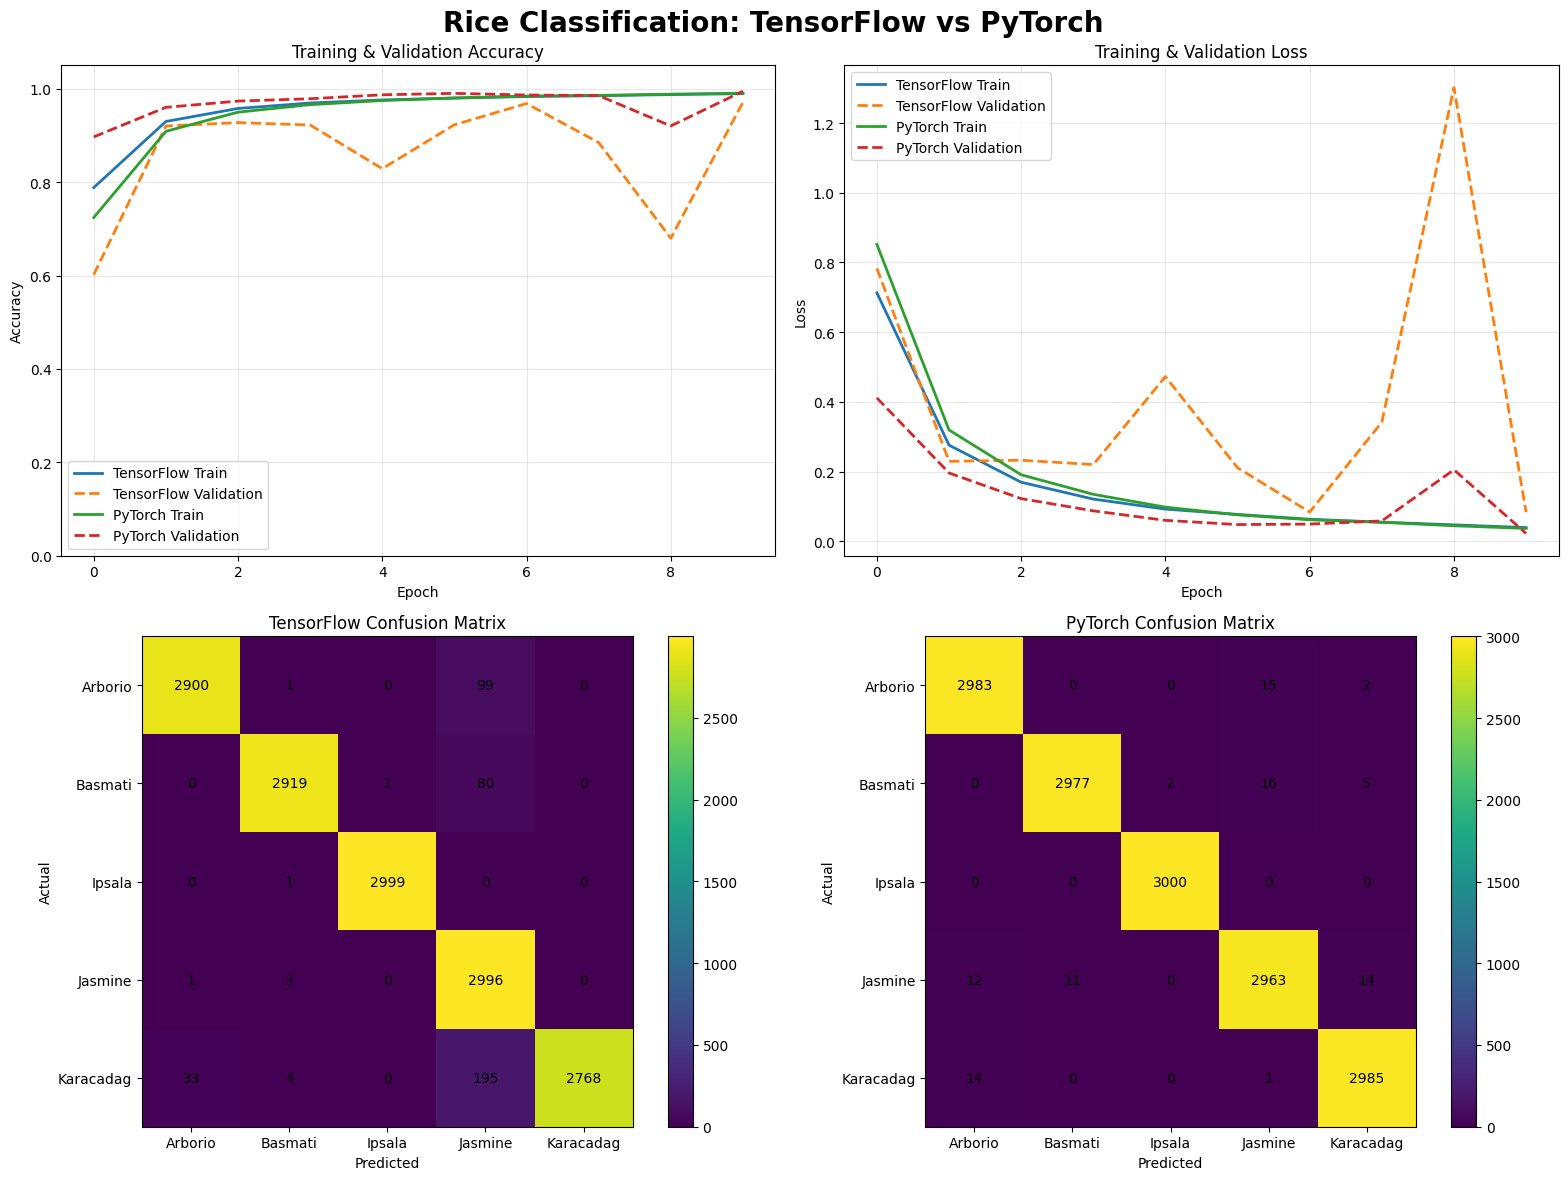

In [ ]:
# ============================================================
# CELL 17: PROFESSIONAL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12),
)

fig.suptitle(
    "Rice Classification: TensorFlow vs PyTorch",
    fontsize=20,
    fontweight="bold",
)


# ============================================================
# 1. Accuracy
# ============================================================

ax = axes[0, 0]

keras_history = history_keras.history

ax.plot(
    keras_history["accuracy"],
    label="TensorFlow Train",
    linewidth=2,
)

ax.plot(
    keras_history["val_accuracy"],
    label="TensorFlow Validation",
    linewidth=2,
    linestyle="--",
)


ax.plot(
    history_torch["train_acc"],
    label="PyTorch Train",
    linewidth=2,
)

ax.plot(
    history_torch["val_acc"],
    label="PyTorch Validation",
    linewidth=2,
    linestyle="--",
)


ax.set_title("Training & Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.set_ylim(0, 1.05)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()


# ============================================================
# 2. Loss
# ============================================================

ax = axes[0, 1]

ax.plot(
    keras_history["loss"],
    label="TensorFlow Train",
    linewidth=2,
)

ax.plot(
    keras_history["val_loss"],
    label="TensorFlow Validation",
    linewidth=2,
    linestyle="--",
)


ax.plot(
    history_torch["train_loss"],
    label="PyTorch Train",
    linewidth=2,
)

ax.plot(
    history_torch["val_loss"],
    label="PyTorch Validation",
    linewidth=2,
    linestyle="--",
)


ax.set_title("Training & Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()


# ============================================================
# 3. TensorFlow Confusion Matrix
# ============================================================

ax = axes[1, 0]

cm_keras = confusion_matrix(
    keras_labels,
    keras_predictions,
)


image = ax.imshow(cm_keras)

ax.set_title(
    "TensorFlow Confusion Matrix"
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm_keras[i, j],
            ha="center",
            va="center",
        )

plt.colorbar(
    image,
    ax=ax,
)


# ============================================================
# 4. PyTorch Confusion Matrix
# ============================================================

ax = axes[1, 1]

cm_torch = confusion_matrix(
    torch_labels,
    torch_predictions,
)


image = ax.imshow(cm_torch)

ax.set_title(
    "PyTorch Confusion Matrix"
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm_torch[i, j],
            ha="center",
            va="center",
        )

plt.colorbar(
    image,
    ax=ax,
)


plt.tight_layout()

comparison_plot_path = (
    RESULTS_DIR / "model_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# ============================================================
# CELL 18: PERFORMANCE SUMMARY
# ============================================================

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Test Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Best Validation Accuracy",
            "Training Time (sec)",
            "Trainable Parameters",
        ],

        "TensorFlow": [
            keras_metrics["Accuracy"],
            keras_metrics["Precision"],
            keras_metrics["Recall"],
            keras_metrics["F1"],
            max(
                keras_history["val_accuracy"]
            ),
            keras_training_time,
            keras_model.count_params(),
        ],

        "PyTorch": [
            torch_metrics["Accuracy"],
            torch_metrics["Precision"],
            torch_metrics["Recall"],
            torch_metrics["F1"],
            max(
                history_torch["val_acc"]
            ),
            torch_training_time,
            sum(
                p.numel()
                for p in torch_model.parameters()
                if p.requires_grad
            ),
        ],
    }
)


print(
    summary_df.to_string(
        index=False
    )
)


# -----------------------------
# Save summary
# -----------------------------

summary_path = (
    RESULTS_DIR / "model_comparison.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

                  Metric    TensorFlow       PyTorch
           Test Accuracy      0.972133      0.993867
               Precision      0.974805      0.993868
                  Recall      0.972133      0.993867
                F1 Score      0.972468      0.993866
Best Validation Accuracy      0.970867      0.994533
     Training Time (sec)   6977.506662   1546.652075
    Trainable Parameters 111301.000000 110853.000000


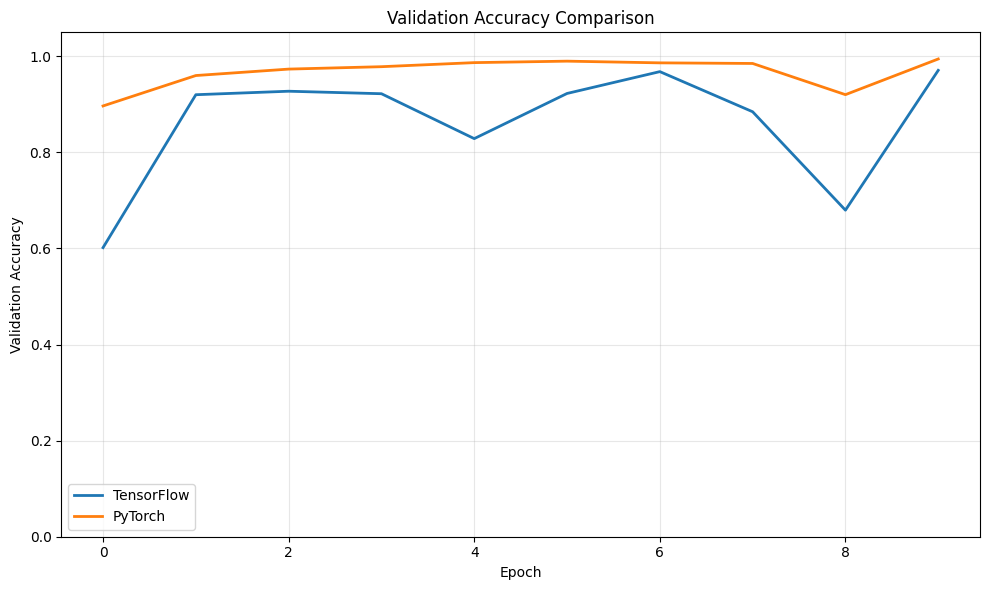

In [ ]:
# ============================================================
# CELL 19: TRAINING CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    keras_history["val_accuracy"],
    label="TensorFlow",
    linewidth=2,
)

ax.plot(
    history_torch["val_acc"],
    label="PyTorch",
    linewidth=2,
)


ax.set_title(
    "Validation Accuracy Comparison"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")

ax.set_ylim(0, 1.05)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()


val_accuracy_plot_path = (
    RESULTS_DIR
    / "validation_accuracy_comparison.png"
)

plt.savefig(
    val_accuracy_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# ============================================================
# CELL 20: SAVE TRAINING HISTORY
# ============================================================

max_epochs = max(
    len(keras_history["loss"]),
    len(history_torch["train_loss"]),
)


def pad_values(
    values,
    length,
):

    values = list(values)

    return values + [
        np.nan
    ] * (
        length - len(values)
    )


training_history_df = pd.DataFrame(
    {
        "Epoch": range(
            1,
            max_epochs + 1,
        ),

        "TF_Train_Accuracy": pad_values(
            keras_history["accuracy"],
            max_epochs,
        ),

        "TF_Val_Accuracy": pad_values(
            keras_history["val_accuracy"],
            max_epochs,
        ),

        "TF_Train_Loss": pad_values(
            keras_history["loss"],
            max_epochs,
        ),

        "TF_Val_Loss": pad_values(
            keras_history["val_loss"],
            max_epochs,
        ),

        "Torch_Train_Accuracy": pad_values(
            history_torch["train_acc"],
            max_epochs,
        ),

        "Torch_Val_Accuracy": pad_values(
            history_torch["val_acc"],
            max_epochs,
        ),

        "Torch_Train_Loss": pad_values(
            history_torch["train_loss"],
            max_epochs,
        ),

        "Torch_Val_Loss": pad_values(
            history_torch["val_loss"],
            max_epochs,
        ),
    }
)


history_path = (
    RESULTS_DIR
    / "training_history.csv"
)

training_history_df.to_csv(
    history_path,
    index=False,
)


print(
    f"Training history saved to:\n"
    f"{history_path}"
)

Training history saved to:
/content/rice_classification/results/training_history.csv


In [ ]:
# ============================================================
# CELL 21: FINAL ARTIFACT SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PROJECT ARTIFACTS")
print("=" * 70)

artifacts = [
    metadata_path,
    keras_checkpoint_path,
    torch_checkpoint_path,
    comparison_plot_path,
    val_accuracy_plot_path,
    summary_path,
    history_path,
]

for artifact in artifacts:

    exists = Path(artifact).exists()

    status = "OK" if exists else "MISSING"

    print(
        f"[{status}] {artifact}"
    )


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    f"TensorFlow Test Accuracy: "
    f"{keras_metrics['Accuracy']:.4f}"
)

print(
    f"PyTorch Test Accuracy:    "
    f"{torch_metrics['Accuracy']:.4f}"
)

print(
    f"TensorFlow Training Time: "
    f"{keras_training_time:.2f} sec"
)

print(
    f"PyTorch Training Time:    "
    f"{torch_training_time:.2f} sec"
)



PROJECT ARTIFACTS
[OK] /content/rice_classification/metadata/dataset_metadata.csv
[OK] /content/rice_classification/models/best_tensorflow.keras
[OK] /content/rice_classification/models/best_pytorch.pt
[OK] /content/rice_classification/results/model_comparison.png
[OK] /content/rice_classification/results/validation_accuracy_comparison.png
[OK] /content/rice_classification/results/model_comparison.csv
[OK] /content/rice_classification/results/training_history.csv


FINAL RESULTS
TensorFlow Test Accuracy: 0.9721
PyTorch Test Accuracy:    0.9939
TensorFlow Training Time: 6977.51 sec
PyTorch Training Time:    1546.65 sec
